In [21]:
#M20-L7

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#init data set

#read and copy
covid_data = pd.read_csv(r'.\data\covid_data.csv', sep=',')
#covid_data = pd.read_csv(r'M20\data\covid_data.csv', sep=',')

vaccinations_data = pd.read_csv(r'.\data\country_vaccinations.csv', sep=',')
#vaccinations_data = pd.read_csv(r'M20\data\country_vaccinations.csv', sep=',')

vaccinations_data = vaccinations_data[
    ['country', 'date', 'total_vaccinations', 
     'people_vaccinated', 'people_vaccinated_per_hundred',
     'people_fully_vaccinated', 'people_fully_vaccinated_per_hundred',
     'daily_vaccinations', 'vaccines']
]

covid_data = covid_data.groupby(
    ['date', 'country'], 
    as_index=False
)[['confirmed', 'deaths', 'recovered']].sum()

covid_data['date'] = pd.to_datetime(covid_data['date'])

covid_data['active'] = covid_data['confirmed'] - covid_data['deaths'] - covid_data['recovered']

covid_data = covid_data.sort_values(by=['country', 'date'])
covid_data['daily_confirmed'] = covid_data.groupby('country')['confirmed'].diff()
covid_data['daily_deaths'] = covid_data.groupby('country')['deaths'].diff()
covid_data['daily_recovered'] = covid_data.groupby('country')['recovered'].diff()

vaccinations_data['date'] = pd.to_datetime(vaccinations_data['date'])

covid_df = covid_data.merge(vaccinations_data, on=['date', 'country'], how='left')
print('Число строк: ', covid_df.shape[0])
print('Число столбцов: ', covid_df.shape[1])

covid_df['death_rate'] = covid_df['deaths'] / covid_df['confirmed'] * 100
covid_df['recover_rate'] =  covid_df['recovered'] / covid_df['confirmed'] * 100

###add in L7
countries = ['Russia', 'Australia', 'Germany', 'Canada', 'United Kingdom']
croped_covid_df = covid_df[covid_df['country'].isin(countries)]

populations = pd.DataFrame([
    ['Canada', 37664517],
    ['Germany', 83721496],
    ['Russia', 145975300],
    ['Australia', 25726900],
    ['United Kingdom', 67802690]
    ],
    columns=['country', 'population']
)
croped_covid_df = croped_covid_df.merge(populations, on=['country'])
croped_covid_df['daily_confirmed_per_hundred'] = croped_covid_df['daily_confirmed'] / croped_covid_df['population'] * 100
croped_covid_df.head()

pivot = croped_covid_df.pivot_table(
    values='people_vaccinated_per_hundred',
    columns='date',
    index='country',
)
pivot.columns = pivot.columns.astype('string')
#display(pivot)

#display(covid_df.info())
#display(covid_df)

Число строк:  86785
Число столбцов:  16


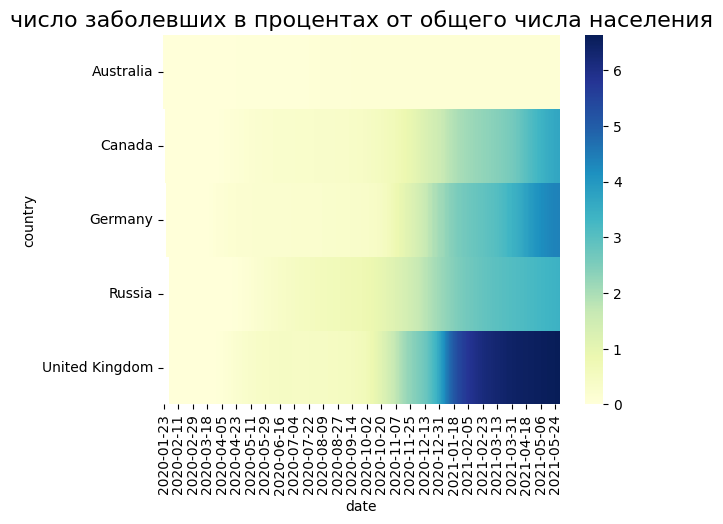

In [22]:
#Задание 6.4

#display(croped_covid_df['confirmed'])
#display(croped_covid_df['population'])
croped_covid_df['confirmed_per_hundred'] = croped_covid_df['confirmed'] / croped_covid_df['population'] * 100

pivot = croped_covid_df.pivot_table(
    values='confirmed_per_hundred',
    columns='date',
    index='country',
)
pivot.columns = pivot.columns.astype('string')
#display(pivot)


heatmap = sns.heatmap(data=pivot, cmap='YlGnBu')
heatmap.set_title('число заболевших в процентах от общего числа населения', fontsize=16);


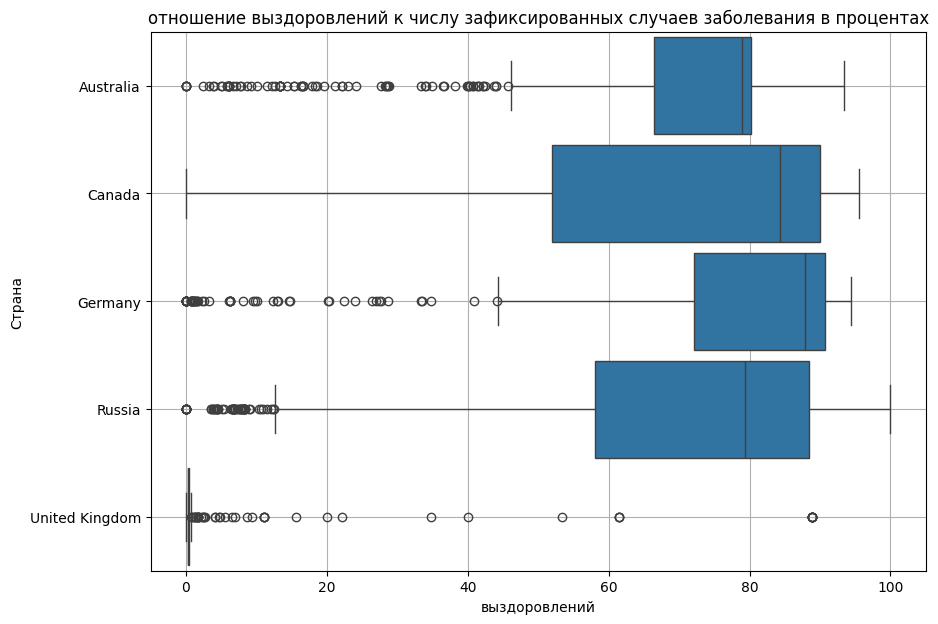

In [25]:
#Задание 6.5


fig = plt.figure(figsize=(10, 7))
boxplot = sns.boxplot(
    data=croped_covid_df,
    y='country',
    x='recover_rate',
    orient='h',
    width=0.9
)
boxplot.set_title('отношение выздоровлений к числу зафиксированных случаев заболевания в процентах');
boxplot.set_xlabel('выздоровлений');
boxplot.set_ylabel('Страна');
boxplot.grid()